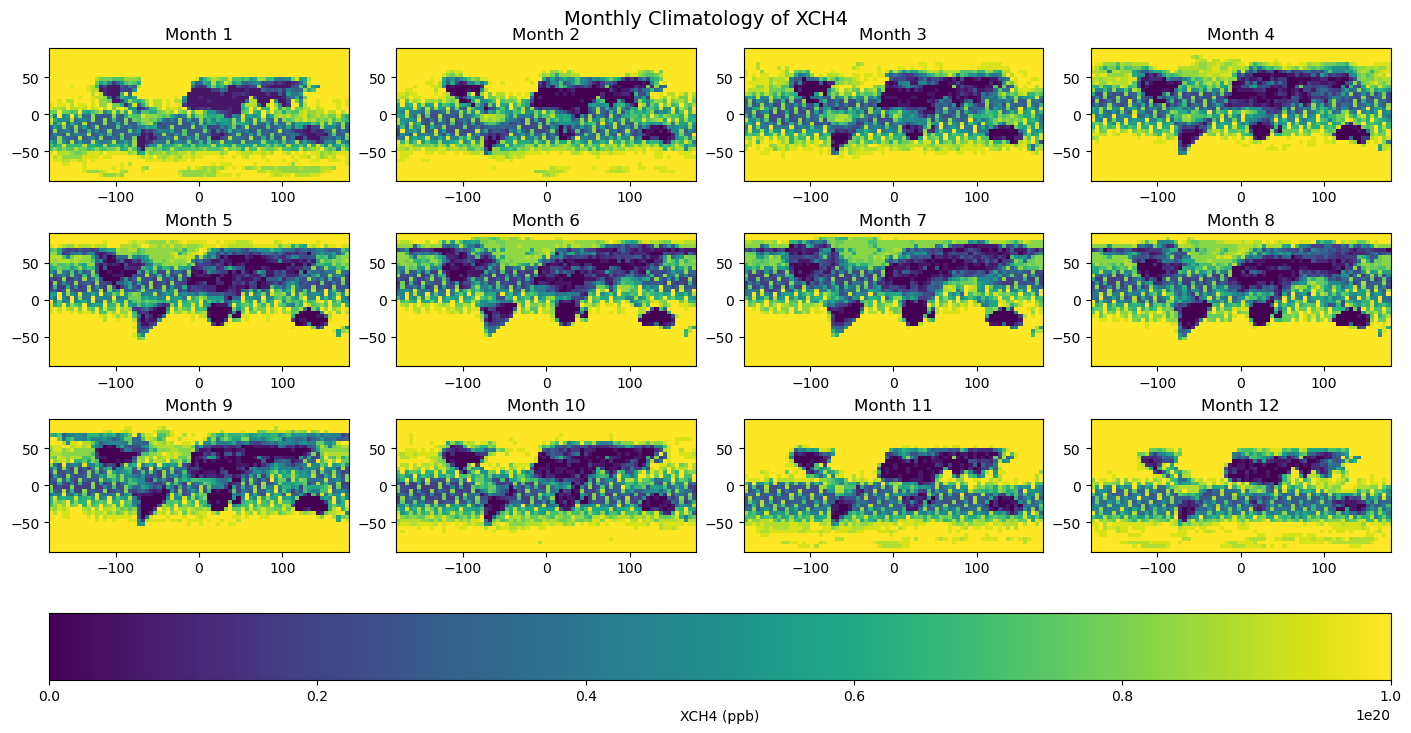

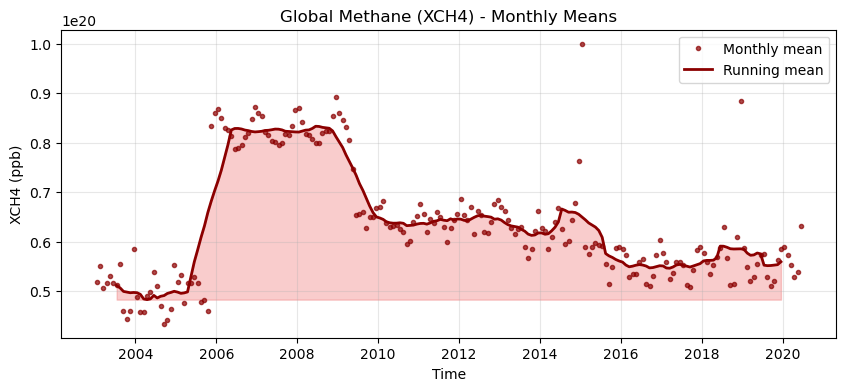

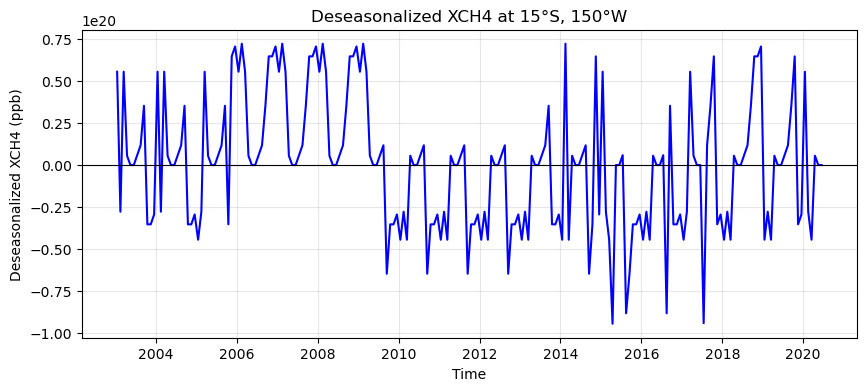

In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# 读数据
ds = xr.open_dataset("C:\\Users\\Libing\\Desktop\\200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc")
ch4 = ds["xch4"]          # (time, lat, lon), 单位 ppb
lat = ds["lat"]
lon = ds["lon"]

# 1.1  每个月的 climatology，12 个面板
# time 维度上按月份分组求平均：得到 12 个月的气候态场
ch4_clim = ch4.groupby("time.month").mean("time")   # (month, lat, lon)

vmin = float(ch4_clim.min())
vmax = float(ch4_clim.max())

fig, axes = plt.subplots(3, 4, figsize=(14, 7), constrained_layout=True)
for m, ax in enumerate(axes.flat, start=1):
    im = ch4_clim.sel(month=m).plot(
        ax=ax, x="lon", y="lat",
        add_colorbar=False, vmin=vmin, vmax=vmax
    )
    ax.set_title(f"Month {m}")
    ax.set_xlabel("")
    ax.set_ylabel("")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(),
                    orientation="horizontal", pad=0.06)
cbar.set_label("XCH4 (ppb)")
fig.suptitle("Monthly Climatology of XCH4", y=1.02, fontsize=14)

# 1.2  全球平均甲烷时间序列（点 + 平滑趋势 + 红色填充）
# cos(lat) 加权全局平均
weights = np.cos(np.deg2rad(lat))
ts_global = ch4.weighted(weights).mean(("lat", "lon"))  # (time,)

# 12 个月滑动平均作为趋势线（中心滑动）
trend = ts_global.rolling(time=13, center=True).mean()

fig, ax = plt.subplots(figsize=(10, 4))

# 月平均值：小点
ax.plot(ts_global["time"], ts_global,
        marker=".", linestyle="none", color="darkred",
        alpha=0.7, label="Monthly mean")

# 趋势线：粗线
ax.plot(ts_global["time"], trend,
        color="darkred", linewidth=2, label="Running mean")

# 填充区域（从趋势线到其最小值），让效果接近题目图
ymin = float(np.nanmin(trend))
ax.fill_between(ts_global["time"], trend, ymin,
                color="lightcoral", alpha=0.4)

ax.set_xlabel("Time")
ax.set_ylabel("XCH4 (ppb)")
ax.set_title("Global Methane (XCH4) - Monthly Means")
ax.grid(True, alpha=0.3)
ax.legend()


# 1.3  [15°S, 150°W] 点的去季节化时间序列
# 选最近格点（lat=-15, lon=-150 是 15°S, 150°W）
ch4_point = ch4.sel(lat=-15, lon=-150, method="nearest")   # (time,)

# 该点的月气候态
clim_point = ch4_point.groupby("time.month").mean("time")  # (month,)

# 去季节：原序列减去对应月份的 climatology
ch4_point_anom = ch4_point.groupby("time.month") - clim_point

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ch4_point["time"], ch4_point_anom,
        color="tabblue" if "tabblue" in plt.rcParams["axes.prop_cycle"].by_key()["color"] else "b")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_xlabel("Time")
ax.set_ylabel("Deseasonalized XCH4 (ppb)")
ax.set_title("Deseasonalized XCH4 at 15°S, 150°W")
ax.grid(True, alpha=0.3)
plt.show()


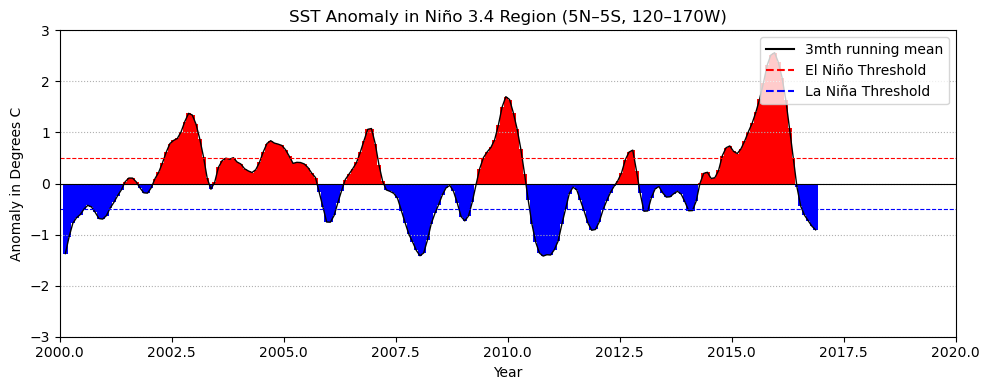

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. 读入数据
ds = xr.open_dataset("C:\\Users\\Libing\\Desktop\\NOAA_NCDC_ERSST_v3b_SST.nc")
sst = ds["sst"]          # (time, lat, lon)
lat = ds["lat"]
lon = ds["lon"]

# 2. 选取 Niño 3.4 区域 (5N–5S, 170W–120W)
# 用条件筛选，避免 lat 顺序不同导致 sel 结果为空
lat_mask = (lat >= -5) & (lat <= 5)
if lon.max() > 180:      # 经度 0–360
    lon_mask = (lon >= 190) & (lon <= 240)   # 170W–120W
else:                    # 经度 -180–180
    lon_mask = (lon >= -170) & (lon <= -120)
sst_n34 = sst.where(lat_mask & lon_mask, drop=True)

# 区域平均（得到一个随 time 变化的一维序列）
nino34 = sst_n34.mean(dim=("lat", "lon"))

# 3. 计算月气候态与距平
clim = nino34.groupby("time.month").mean("time")   # 12 个月气候态
anom = nino34.groupby("time.month") - clim         # 距平

# 只画 2000–2019 年
anom = anom.sel(time=slice("2000-01-01", "2019-12-31"))

# 4. 3 个月滑动平均
nino34_3m = anom.rolling(time=3, center=True).mean()

# 5. 准备画图数据：把 time 转成年份浮点数，并去掉 NaN
years = nino34_3m["time.year"].values
months = nino34_3m["time.month"].values
x = years + (months - 0.5) / 12.0        # 年份中点
vals = nino34_3m.values
mask = ~np.isnan(vals)
x = x[mask]
vals = vals[mask]

# 6. 作图
fig, ax = plt.subplots(figsize=(10, 4))

# 条形：正值红色，负值蓝色
colors = np.where(vals >= 0, "r", "b")
ax.bar(x, vals, color=colors, width=0.10)

# 黑色折线表示 3 个月滑动平均
ax.plot(x, vals, "k-", linewidth=1)

# 0 线和 El Niño / La Niña 阈值
ax.axhline(0, color="k", linewidth=0.8)
ax.axhline(0.5, color="r", linestyle="--", linewidth=0.8)
ax.axhline(-0.5, color="b", linestyle="--", linewidth=0.8)
ax.set_xlim(2000, 2020)
ax.set_ylim(-3, 3)
ax.set_ylabel("Anomaly in Degrees C")
ax.set_xlabel("Year")
ax.set_title("SST Anomaly in Niño 3.4 Region (5N–5S, 120–170W)")

# 图例
legend_lines = [
    Line2D([0], [0], color="k", label="3mth running mean"),
    Line2D([0], [0], color="r", linestyle="--", label="El Niño Threshold"),
    Line2D([0], [0], color="b", linestyle="--", label="La Niña Threshold"),
]
ax.legend(handles=legend_lines, loc="upper right")
ax.grid(axis="y", linestyle=":")
plt.tight_layout()
plt.show()

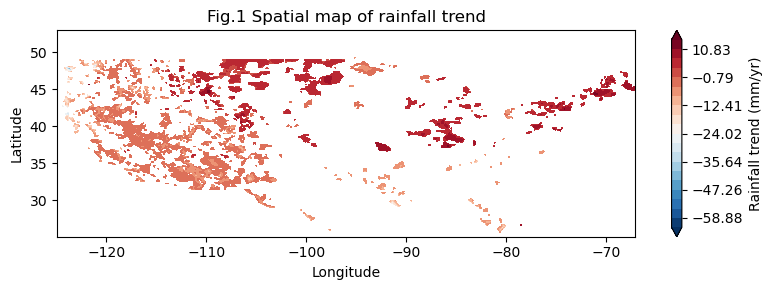

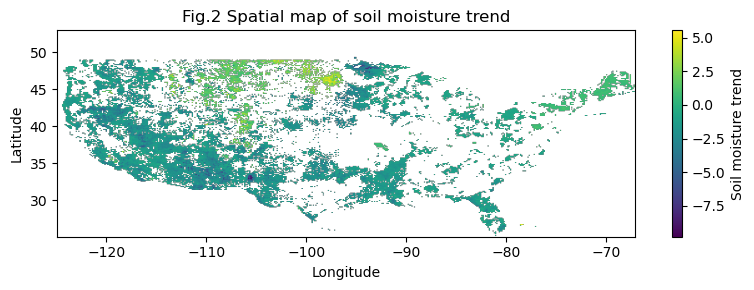

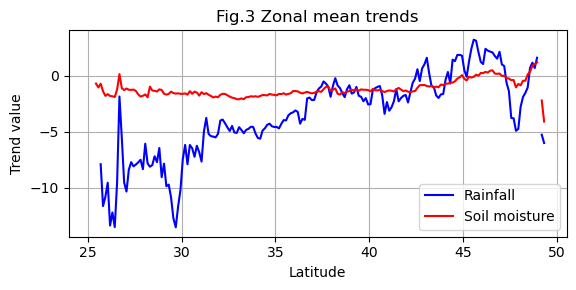

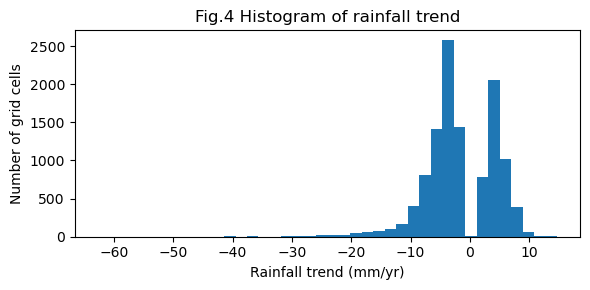

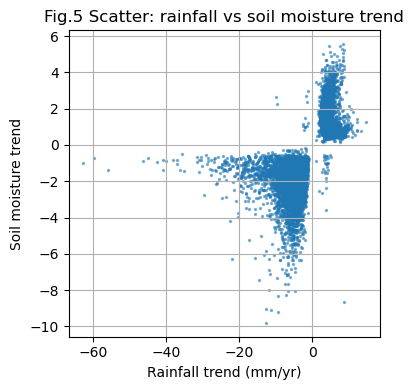

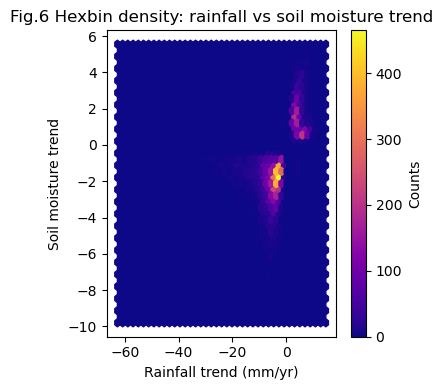

In [16]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd   # 虽然用得少，但题目允许就保留

# 1. 读数据
ds = xr.open_dataset("C:\\Users\\Libing\\Desktop\\NCALDAS_NOAH0125_Trends.A198010_201509.002.nc")

# 选择两个变量：降水趋势、土壤湿度趋势
rain = ds["Trend_Rainf_f"].squeeze("time")    # (lat, lon)
soil = ds["Trend_SoilMoist"].squeeze("time")  # (lat, lon)

# 处理缺测值
if "missing_value" in ds.attrs:
    mv = ds.attrs["missing_value"]
    rain = rain.where(rain != mv)
    soil = soil.where(soil != mv)

lat = ds["lat"].values
lon = ds["lon"].values

# Fig.1 空间分布：降水趋势 contourf
plt.figure(figsize=(8, 3))
levels = np.linspace(float(rain.min()), float(rain.max()), 21)
cs = plt.contourf(lon, lat, rain.values,
                  levels=levels, cmap="RdBu_r", extend="both")
plt.colorbar(cs, label="Rainfall trend (mm/yr)")
plt.title("Fig.1 Spatial map of rainfall trend")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

# Fig.2 空间分布：土壤湿度趋势 imshow
plt.figure(figsize=(8, 3))
im = plt.imshow(soil.values, origin="lower",
                extent=[lon.min(), lon.max(), lat.min(), lat.max()],
                aspect="auto", cmap="viridis")
plt.colorbar(im, label="Soil moisture trend")
plt.title("Fig.2 Spatial map of soil moisture trend")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

# Fig.3 两条折线：纬向平均趋势 vs 纬度（蓝线+红线）
zonal_rain = rain.mean(dim="lon", skipna=True)  # (lat,)
zonal_soil = soil.mean(dim="lon", skipna=True)

plt.figure(figsize=(6, 3))
plt.plot(lat, zonal_rain.values, "b-", label="Rainfall")
plt.plot(lat, zonal_soil.values, "r-", label="Soil moisture")
plt.title("Fig.3 Zonal mean trends")
plt.xlabel("Latitude")
plt.ylabel("Trend value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Fig.4 直方图：降水趋势分布
rain_flat = rain.values.ravel()
rain_flat = rain_flat[np.isfinite(rain_flat)]

plt.figure(figsize=(6, 3))
plt.hist(rain_flat, bins=40)
plt.title("Fig.4 Histogram of rainfall trend")
plt.xlabel("Rainfall trend (mm/yr)")
plt.ylabel("Number of grid cells")
plt.tight_layout()
plt.show()

# Fig.5 散点图：降水趋势 vs 土壤湿度趋势
soil_flat = soil.values.ravel()
mask = np.isfinite(rain_flat)  # rain_flat 已去掉 NaN，这里简单重算一遍更稳妥
rain_flat2 = rain.values.ravel()
soil_flat2 = soil.values.ravel()
mask = np.isfinite(rain_flat2) & np.isfinite(soil_flat2)
rain_flat2 = rain_flat2[mask]
soil_flat2 = soil_flat2[mask]

plt.figure(figsize=(4, 4))
plt.scatter(rain_flat2, soil_flat2, s=2, alpha=0.5)
plt.title("Fig.5 Scatter: rainfall vs soil moisture trend")
plt.xlabel("Rainfall trend (mm/yr)")
plt.ylabel("Soil moisture trend")
plt.grid(True)
plt.tight_layout()
plt.show()

# Fig.6 hexbin：二维密度图（参考 cheat sheet 中 hexbin 示例）
plt.figure(figsize=(4, 4))
hb = plt.hexbin(rain_flat2, soil_flat2, gridsize=40, cmap="plasma")
plt.colorbar(hb, label="Counts")
plt.title("Fig.6 Hexbin density: rainfall vs soil moisture trend")
plt.xlabel("Rainfall trend (mm/yr)")
plt.ylabel("Soil moisture trend")
plt.tight_layout()
plt.show()